# How the microhard neural net works

A step-through of the segmentation network on **real UHCS micrographs**, on the MacBook GPU (MPS).

The architecture in one sentence: a **frozen resnet50 encoder** (NASA MicroNet weights, shared by
every task) turns the image into a pyramid of feature maps, and a **trainable U-Net decoder head**
turns that pyramid back into a per-pixel score for each taxonomy node
(`ferrous/matrix`, `ferrous/network`, `ferrous/spheroidite`, `ferrous/widmanstatten`).

Run order matters — later cells reuse earlier objects. Everything here is the same code the CLI
uses (`microhard train-seg` / `predict`); nothing is notebook-only magic.

In [1]:
import os, time
from pathlib import Path

import numpy as np
import torch
from PIL import Image
from IPython.display import display

# notebook lives in notebooks/; run everything from the project root
if not Path("data").exists() and Path("../data").exists():
    os.chdir("..")

from microhard.config import Config
from microhard.taxonomy import Taxonomy

torch.manual_seed(0)
cfg = Config.load("demo.toml")
taxonomy = Taxonomy.load(cfg.taxonomy_path)
cfg

Config(data_dir=PosixPath('data'), checkpoint_dir=PosixPath('checkpoints'), taxonomy_path=None, adapters=['uhcs'], encoder='resnet50', encoder_weights='micronet', micronet_url='https://nasa-public-data.s3.amazonaws.com/microscopy_segmentation_models/resnet50_pretrained_microscopynet_v1.1.pth.tar', image_size=484, batch_size=4, lr=0.0003, epochs=14, num_workers=0, device='auto', val_frac=0.2, test_frac=0.15, seed=42, router_alpha=0.1, router_calib_frac=0.25)

## 1 · The MacBook GPU

`Config.resolve_device()` picks `mps` automatically on Apple Silicon. The assert below is the
guarantee this notebook is *not* quietly falling back to CPU.

In [2]:
print("torch", torch.__version__)
print("MPS available:", torch.backends.mps.is_available())
device = cfg.resolve_device()
print("resolved device:", device)
assert device.type == "mps", "expected the MacBook GPU — check torch install"

x = torch.randn(2, 3, 64, 64, device=device)
print("test tensor lives on:", x.device)

torch 2.13.0
MPS available: True
resolved device: mps


test tensor lives on: mps:0


## 2 · The data: micrograph + pixel-level ground truth

`UHCSAdapter` turns the sqlite + downloaded files into canonical records; 24 of them carry
pixel masks from the DeCost benchmark. Mask integer *i* means taxonomy node
`record.mask_class_nodes[i]` — labels are never bare strings.

In [3]:
from microhard.adapters.uhcs import SEG_CLASS_NODES, UHCSAdapter

adapter = UHCSAdapter(cfg, taxonomy)
records = adapter.validated_records()
masked = [r for r in records if r.mask_path is not None]
on_disk = [r for r in records if r.image_path.exists()]
print(f"{len(records)} records in UHCSDB, {len(on_disk)} images on disk, {len(masked)} with masks")

rec = masked[0]
print("record:", rec.record_id, "| sample group:", rec.group_id,
      "| scale:", rec.scale_um_per_px, "µm/px")
print("mask classes:", rec.mask_class_nodes)

961 records in UHCSDB, 51 images on disk, 24 with masks
record: uhcs-6 | sample group: uhcs-sample-29.0 | scale: 0.16129032258064516 µm/px
mask classes: ('ferrous/matrix', 'ferrous/network', 'ferrous/spheroidite', 'ferrous/widmanstatten')


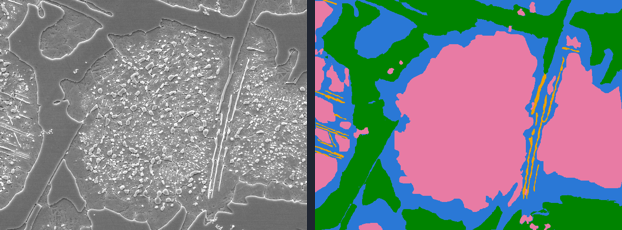

left: SEM input · right: human pixel labels (blue matrix, green network, magenta spheroidite, yellow Widmanstätten)


In [4]:
# display helpers: PIL only (no plotting dependency)
COLORS = np.array([[42, 120, 214],   # ferrous/matrix        (blue)
                   [0, 131, 0],      # ferrous/network       (green)
                   [232, 123, 164],  # ferrous/spheroidite   (magenta)
                   [237, 161, 0]],   # ferrous/widmanstatten (yellow)
                  dtype=np.uint8)

def colorize(mask):
    return Image.fromarray(COLORS[mask])

def row(*ims, h=230, gap=8):
    ims = [im.convert("RGB").resize((round(im.width * h / im.height), h)) for im in ims]
    out = Image.new("RGB", (sum(im.width for im in ims) + gap * (len(ims) - 1), h), "#202632")
    x = 0
    for im in ims:
        out.paste(im, (x, 0)); x += im.width + gap
    return out

image = Image.open(rec.image_path)
gt_mask = np.asarray(Image.open(rec.mask_path))
display(row(image, colorize(gt_mask)))
print("left: SEM input · right: human pixel labels "
      "(blue matrix, green network, magenta spheroidite, yellow Widmanstätten)")

## 3 · The frozen backbone: what the encoder "sees"

The resnet50 encoder is materialized **once** to `checkpoints/backbone.pt` (MicroNet weights —
pretrained on 100k+ microscopy images) and frozen: `requires_grad=False`, BatchNorm pinned in
eval. Feeding it a micrograph yields a **feature pyramid** — six tensors, each half the
resolution and (roughly) twice the channels of the last.

In [5]:
from microhard.backbone import build_encoder, freeze
from microhard.transforms import seg_eval_transforms

encoder = freeze(build_encoder(cfg)).to(device)
print(f"encoder parameters: {sum(p.numel() for p in encoder.parameters())/1e6:.1f} M — all frozen")

batch = seg_eval_transforms()(image=np.asarray(image.convert("RGB")))["image"].unsqueeze(0).to(device)
print("input batch:", tuple(batch.shape), "on", batch.device, "(645×484 padded to /32)")

with torch.no_grad():
    pyramid = encoder(batch)
for depth, feats in enumerate(pyramid):
    print(f"  stage {depth}: {tuple(feats.shape)}")

encoder parameters: 23.5 M — all frozen
input batch: (1, 3, 512, 672) on mps:0 (645×484 padded to /32)


  stage 0: (1, 3, 512, 672)
  stage 1: (1, 64, 256, 336)
  stage 2: (1, 256, 128, 168)
  stage 3: (1, 512, 64, 84)
  stage 4: (1, 1024, 32, 42)
  stage 5: (1, 2048, 16, 21)


stage-1 channels — edge/texture detectors at near-full resolution:


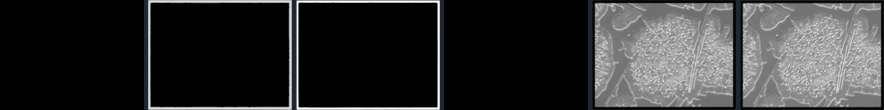

stage-4 channels — coarse, semantic responses (constituent-scale blobs):


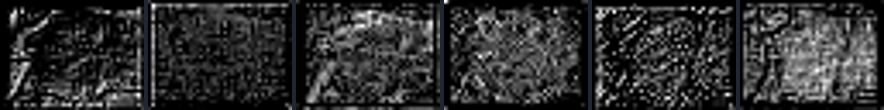

In [6]:
def show_channels(feats, n=6, h=110):
    f = feats[0].float().cpu()
    panels = []
    for c in range(n):
        a = f[c]
        a = (a - a.min()) / (a.max() - a.min() + 1e-8)
        panels.append(Image.fromarray((a * 255).byte().numpy()))
    display(row(*panels, h=h, gap=4))

print("stage-1 channels — edge/texture detectors at near-full resolution:")
show_channels(pyramid[1])
print("stage-4 channels — coarse, semantic responses (constituent-scale blobs):")
show_channels(pyramid[4])

## 4 · The trainable part: a U-Net decoder head

`smp.Unet` walks the pyramid back up, at each step upsampling and concatenating the matching
encoder stage (the "skip connections"), and ends with a 1×1 conv producing **one score map per
taxonomy node**. Only this decoder trains — the parameter count shows how small the trainable
surface is.

In [7]:
from microhard.backbone import trainable_parameters
from microhard.segment import build_segmentation_model

model = build_segmentation_model(cfg, num_classes=len(SEG_CLASS_NODES)).to(device)
frozen_n = sum(p.numel() for p in model.parameters() if not p.requires_grad)
train_n = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"frozen encoder:            {frozen_n/1e6:5.1f} M parameters")
print(f"trainable decoder + head:  {train_n/1e6:5.1f} M parameters")

with torch.no_grad():
    logits = model(batch)
print("\nlogits:", tuple(logits.shape), "— one score map per class:")
for i, node in enumerate(SEG_CLASS_NODES):
    print(f"  channel {i} → {node}")
print("prediction = argmax over channels, per pixel")

frozen encoder:             23.5 M parameters
trainable decoder + head:    9.0 M parameters



logits: (1, 4, 512, 672) — one score map per class:
  channel 0 → ferrous/matrix
  channel 1 → ferrous/network
  channel 2 → ferrous/spheroidite
  channel 3 → ferrous/widmanstatten
prediction = argmax over channels, per pixel


### GPU vs CPU — why MPS matters here

In [8]:
def bench(dev, n=3):
    m, b = model.to(dev), batch.to(dev)
    with torch.no_grad():
        m(b)                                    # warm-up
        if dev.type == "mps": torch.mps.synchronize()
        t0 = time.perf_counter()
        for _ in range(n): m(b)
        if dev.type == "mps": torch.mps.synchronize()
    return (time.perf_counter() - t0) / n

mps_ms = bench(device) * 1000
cpu_ms = bench(torch.device("cpu")) * 1000
model.to(device)
print(f"full-frame forward pass:  MPS {mps_ms:6.0f} ms   CPU {cpu_ms:6.0f} ms   → {cpu_ms/mps_ms:.1f}× speedup")

full-frame forward pass:  MPS    674 ms   CPU   1796 ms   → 2.7× speedup


## 5 · Augmentation: what one training example becomes

Square 480 px random crops (a non-square frame can't survive `RandomRotate90` inside a batch),
flips/rotations, brightness–contrast jitter. Padding, never resizing — resizing would corrupt
the physical µm/px scale. Image and mask go through the same geometric transform.

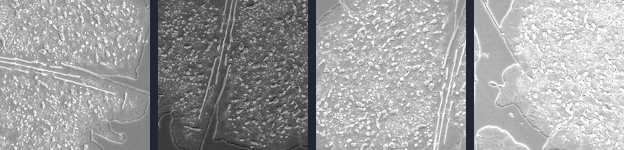

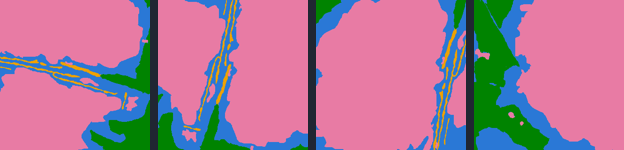

four random draws of the same record — image (top) and mask (bottom) transformed together


In [9]:
import albumentations as A

aug = A.Compose([
    A.RandomCrop(320, 320),
    A.HorizontalFlip(p=0.5), A.VerticalFlip(p=0.5), A.RandomRotate90(p=0.5),
    A.RandomBrightnessContrast(p=0.9),
])
draws = [aug(image=np.asarray(image.convert("RGB")), mask=gt_mask) for _ in range(4)]
display(row(*[Image.fromarray(d["image"]) for d in draws], h=150))
display(row(*[colorize(d["mask"]) for d in draws], h=150))
print("four random draws of the same record — image (top) and mask (bottom) transformed together")

## 6 · Training, written out

The actual loop from `segment.py`, inlined: Dice loss (region overlap) + cross-entropy
(per-pixel), AdamW over **trainable parameters only**, split **by physical sample** so
validation samples are never seen in training. Watch the decoder learn on the GPU — 4 epochs
is enough to see structure emerge.

In [10]:
import segmentation_models_pytorch as smp
from torch.utils.data import DataLoader

from microhard.records import RecordSegmentationDataset, split_records_by_group
from microhard.segment import evaluate_segmentation, segment_image
from microhard.transforms import seg_train_transforms

splits = split_records_by_group(masked, val_frac=0.2, test_frac=0.0, seed=cfg.seed)
train_recs, val_recs = splits["train"], splits["val"]
print(f"{len(train_recs)} train / {len(val_recs)} val records "
      f"({len({r.group_id for r in train_recs})} vs {len({r.group_id for r in val_recs})} samples)")

train_loader = DataLoader(RecordSegmentationDataset(train_recs, seg_train_transforms(cfg.image_size)),
                          batch_size=4, shuffle=True)
val_loader = DataLoader(RecordSegmentationDataset(val_recs, seg_eval_transforms()), batch_size=4)

net = build_segmentation_model(cfg, num_classes=len(SEG_CLASS_NODES)).to(device)
dice = smp.losses.DiceLoss(mode="multiclass", from_logits=True)
ce = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(trainable_parameters(net), lr=cfg.lr)

val_rec = val_recs[0]
val_image = np.asarray(Image.open(val_rec.image_path).convert("RGB"))
before = segment_image(net, val_image, device)     # untrained decoder: noise

for epoch in range(4):
    net.train(); net.encoder.eval()                # frozen BN must not drift
    total = 0.0
    for images, masks_b in train_loader:
        images, masks_b = images.to(device), masks_b.to(device)
        optimizer.zero_grad()
        out = net(images)
        loss = dice(out, masks_b) + ce(out, masks_b)
        loss.backward()
        optimizer.step()
        total += loss.item() * len(images)
    miou = evaluate_segmentation(net, val_loader, device, len(SEG_CLASS_NODES))
    print(f"epoch {epoch+1}/4   loss {total/len(train_recs):.3f}   val mIoU {miou:.3f}")

after = segment_image(net, val_image, device)

17 train / 7 val records (10 vs 2 samples)


epoch 1/4   loss 2.437   val mIoU 0.095


epoch 2/4   loss 2.122   val mIoU 0.103


epoch 3/4   loss 1.915   val mIoU 0.140


epoch 4/4   loss 1.736   val mIoU 0.258


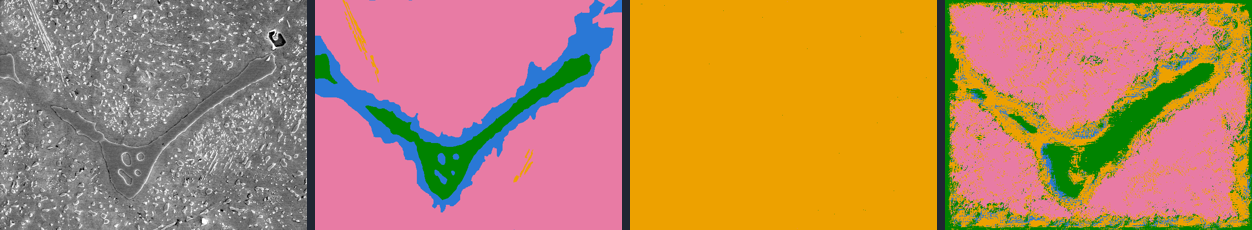

input · ground truth · untrained decoder · after 4 epochs


In [11]:
gt_val = np.asarray(Image.open(val_rec.mask_path))
display(row(Image.fromarray(val_image), colorize(gt_val), colorize(before), colorize(after)))
print("input · ground truth · untrained decoder · after 4 epochs")

## 7 · The trained checkpoint (14 epochs, val mIoU 0.495)

`microhard train-seg` already ran the same loop for 14 epochs — load its checkpoint and compare
on the same held-out image (identical split function + seed, so it is held-out for the
checkpoint too).

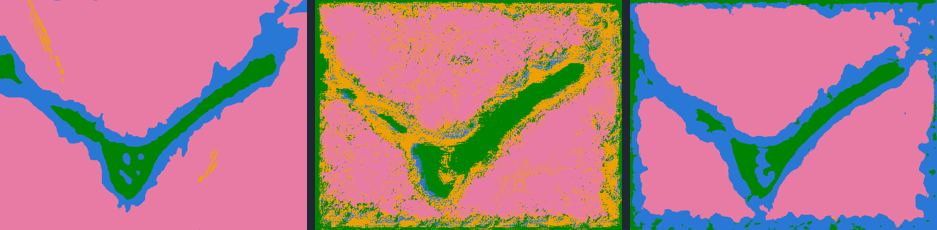

ground truth · notebook (4 epochs) · checkpoint (14 epochs)


{'ferrous/matrix': 0.373,
 'ferrous/network': 0.497,
 'ferrous/spheroidite': 0.775,
 'ferrous/widmanstatten': 0.0}

In [12]:
from microhard.segment import load_segmenter

best_net, class_nodes = load_segmenter(cfg)
best_net.to(device)
best = segment_image(best_net, val_image, device)
display(row(colorize(gt_val), colorize(after), colorize(best)))
print("ground truth · notebook (4 epochs) · checkpoint (14 epochs)")

inter = ((best == gt_val) & (gt_val >= 0)).sum()
per_class = {}
for i, node in enumerate(class_nodes):
    p, g = best == i, gt_val == i
    union = (p | g).sum()
    per_class[node] = round(float((p & g).sum() / union), 3) if union else None
per_class

## 8 · From pixels to properties

The mask collapses into a **FeatureVector** — fractions and morphology keyed by taxonomy id —
which is all any property head is ever allowed to see. With `hardness_labels.csv` still empty,
the hardness head abstains instead of guessing.

In [13]:
from microhard.features import image_feature_vector
from microhard.pipeline import predict_image

fv = image_feature_vector(best, tuple(class_nodes), "ferrous")
for node in class_nodes:
    frac = fv.get(f"frac:{node}")
    print(f"{node:<24s} {'█' * round(frac * 40):<40s} {frac:6.1%}")

result = predict_image(cfg, val_rec.image_path, family="ferrous")
print("\nproperties:", result.properties or "(none)")
print("abstentions:", result.abstentions)

ferrous/matrix           ██████████                                25.5%
ferrous/network          ████                                       9.4%
ferrous/spheroidite      ██████████████████████████                65.0%
ferrous/widmanstatten                                               0.1%



properties: (none)
abstentions: {'hardness_hv': 'no calibrated model for (ferrous/uhcs, hardness_hv) — insufficient calibration data or fit not run'}


## Where to go from here

| notebook cell | production command |
|---|---|
| §6 training loop | `uv run microhard train-seg -c demo.toml` |
| §8 features | `uv run microhard extract-features -c demo.toml` |
| §8 prediction | `uv run microhard predict <image> --family ferrous -c demo.toml` |

Next levers: `scripts/fetch_uhcs_mirror.py --all` (all 961 images), transcribe HV rows into
`data/hardness_labels.csv` then `microhard fit-hardness`, and `microhard train-router` once a
second family has real images.